# RetailPulse – AI-Powered Customer Analytics & Demand Forecasting Platform

## Module F-02: Customer Segmentation

Objectives:
- RFM Analysis
- Behavioral Segmentation
- K-Means Clustering
- DBSCAN Clustering
- Customer Personas
- Business Interpretation

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [30]:
rfm = pd.read_csv("../data/processed/customer_rfm.csv")

print("Shape:", rfm.shape)
rfm.head()

Shape: (4383, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346.0,67,15,-51.74
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,4,2646.99
4,12351.0,11,1,300.93


In [31]:
# Remove customers with negative spend

rfm = rfm[rfm["Monetary"] > 0].copy()

print("Remaining customers:", len(rfm))

Remaining customers: 4283


In [32]:
rfm.info()

<class 'pandas.DataFrame'>
Index: 4283 entries, 1 to 4382
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  4283 non-null   float64
 1   Recency      4283 non-null   int64  
 2   Frequency    4283 non-null   int64  
 3   Monetary     4283 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 167.3 KB


In [33]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,4283.000000,4283.000000,4283.000000,4.283000e+03
mean,15352.238151,88.529302,5.454588,1.963459e+03
std,1701.244885,95.716440,10.147717,8.593185e+03
min,12347.000000,1.000000,1.000000,8.881784e-16
25%,13883.500000,17.000000,1.000000,3.010900e+02
50%,15358.000000,50.000000,3.000000,6.794400e+02
75%,16834.500000,130.000000,6.000000,1.676590e+03
max,18287.000000,374.000000,270.000000,3.417767e+05


In [34]:
rfm.isnull().sum()

Customer ID    0
Recency        0
Frequency      0
Monetary       0
dtype: int64

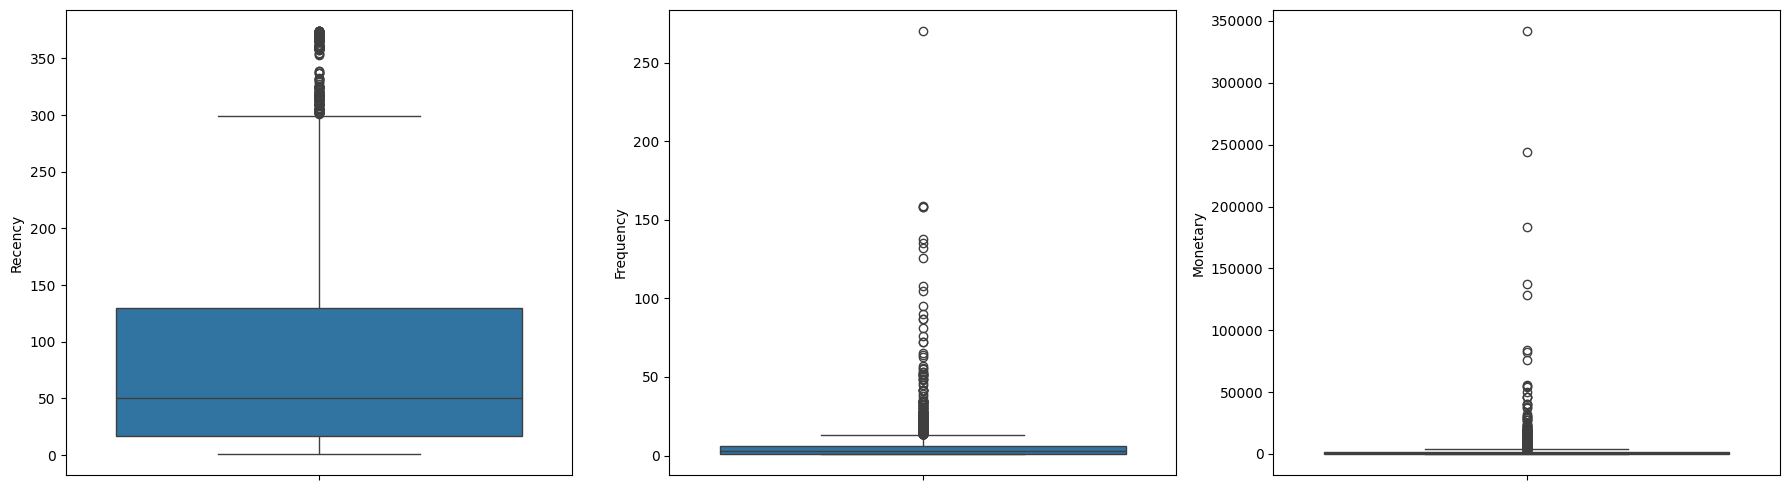

In [35]:
fig, ax = plt.subplots(1,3, figsize=(18,5))

sns.boxplot(y=rfm["Recency"], ax=ax[0])
sns.boxplot(y=rfm["Frequency"], ax=ax[1])
sns.boxplot(y=rfm["Monetary"], ax=ax[2])

plt.tight_layout()
plt.show()

In [36]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [37]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

In [38]:
def customer_segment(row):

    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    elif r >= 4 and f >= 2:
        return "Potential Loyalists"

    elif r == 5 and f == 1:
        return "New Customers"

    elif r >= 3 and f <= 2:
        return "Promising Customers"

    elif r <= 2 and f >= 3:
        return "At Risk"

    elif r <= 2 and m >= 4:
        return "Cannot Lose Them"

    else:
        return "Lost Customers"

In [39]:
rfm["Segment"] = rfm.apply(
    customer_segment,
    axis=1
)

In [40]:
rfm["Segment"].value_counts()

Segment
Lost Customers         1138
Champions               917
At Risk                 701
Potential Loyalists     530
Loyal Customers         471
Promising Customers     425
Cannot Lose Them         54
New Customers            47
Name: count, dtype: int64

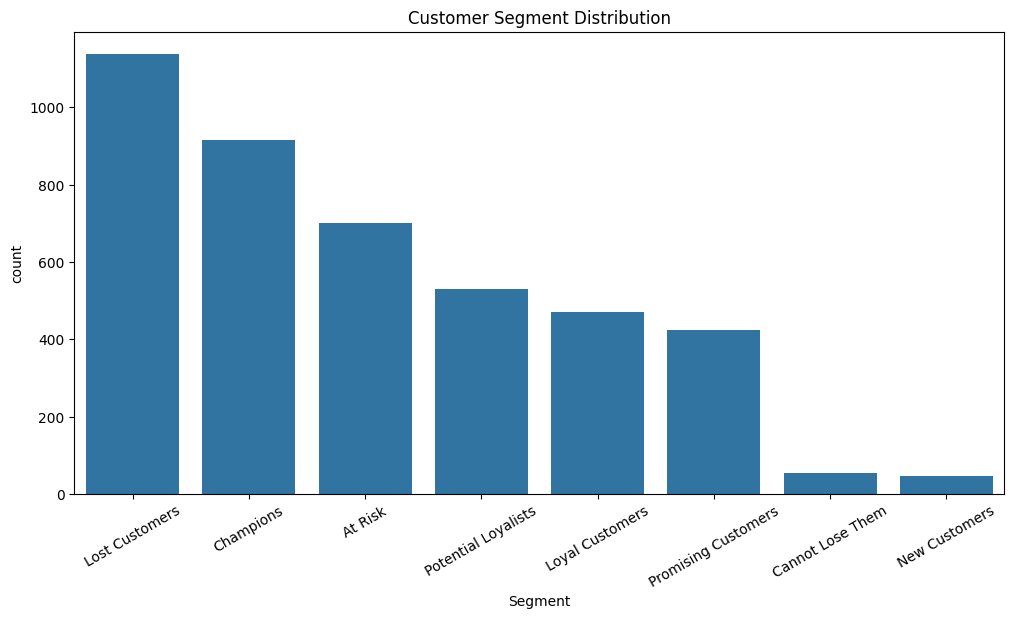

In [41]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=rfm,
    x="Segment",
    order=rfm["Segment"].value_counts().index
)

plt.xticks(rotation=30)
plt.title("Customer Segment Distribution")
plt.show()

In [42]:
segment_summary = rfm.groupby("Segment")[
    ["Recency","Frequency","Monetary"]
].mean().round(2)

segment_summary

,Recency,Frequency,Monetary
Segment,,,
At Risk,146.12,4.64,1330.35
Cannot Lose Them,176.50,1.56,2071.71
Champions,12.55,14.48,6008.41
Lost Customers,183.18,1.49,397.85
Loyal Customers,39.15,6.82,1742.85
New Customers,7.70,1.00,349.89
Potential Loyalists,17.36,2.35,721.64
Promising Customers,45.27,1.28,430.09


In [43]:
segment_summary.to_csv(
    "../data/processed/segment_summary.csv"
)

print("segment_summary.csv saved")

segment_summary.csv saved


In [44]:
revenue = rfm.groupby(
    "Segment"
)["Monetary"].sum().sort_values(
    ascending=False
)

revenue

Segment
Champions              5509708.267
At Risk                 932578.621
Loyal Customers         820881.781
Lost Customers          452750.482
Potential Loyalists     382470.951
Promising Customers     182788.790
Cannot Lose Them        111872.132
New Customers            16445.050
Name: Monetary, dtype: float64

In [45]:
features = rfm[
    ["Recency","Frequency","Monetary"]
]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(features)

In [46]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)

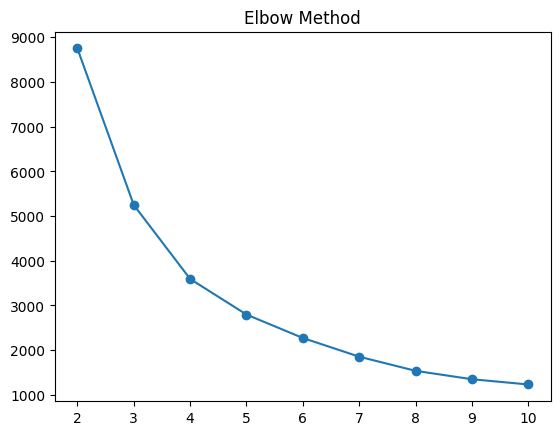

In [47]:
plt.plot(range(2,11), inertia, marker="o")
plt.title("Elbow Method")
plt.show()

## K-Means Cluster Selection

Based on the Elbow Method, K = 4 was selected as the optimal number of clusters.

This provides meaningful customer groups while maintaining cluster separation and interpretability.

In [48]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["KMeans_Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

In [49]:
score = silhouette_score(
    rfm_scaled,
    rfm["KMeans_Cluster"]
)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.61


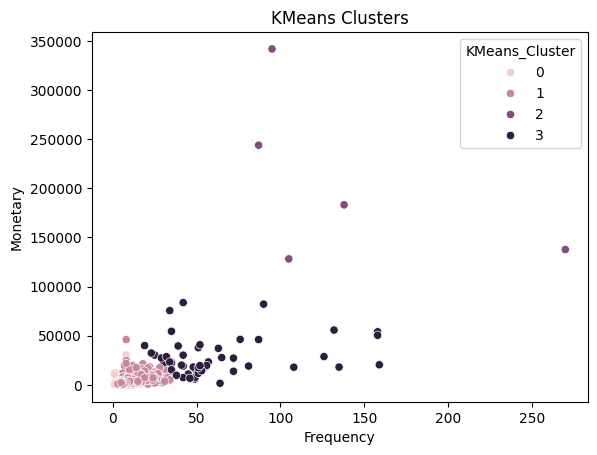

In [50]:
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="KMeans_Cluster"
)

plt.title("KMeans Clusters")
plt.show()

In [51]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

rfm["DBSCAN_Cluster"] = dbscan.fit_predict(
    rfm_scaled
)

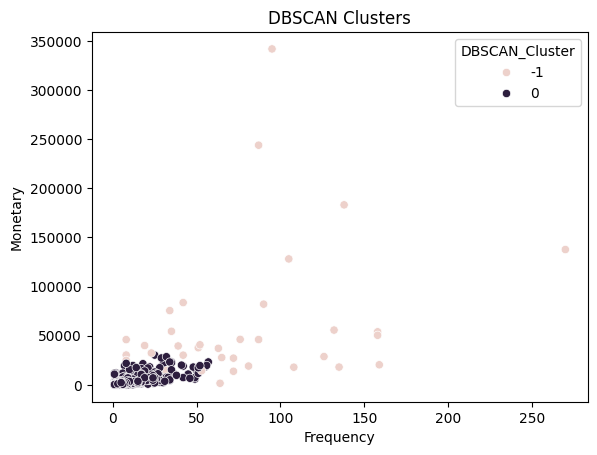

In [52]:
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="DBSCAN_Cluster"
)

plt.title("DBSCAN Clusters")
plt.show()

In [53]:
outliers = rfm[
    rfm["DBSCAN_Cluster"] == -1
]

print(
    "Outlier Customers:",
    len(outliers)
)

outliers.head()

Outlier Customers: 36


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,KMeans_Cluster,DBSCAN_Cluster
88,12471.0,8,81,19197.49,5,5,5,555,Champions,3,-1
96,12482.0,85,32,21893.53,2,5,5,255,At Risk,3,-1
254,12748.0,1,159,20491.27,5,5,5,555,Champions,3,-1
387,12931.0,16,51,37836.86,4,5,5,455,Champions,3,-1
511,13089.0,4,132,55801.73,5,5,5,555,Champions,3,-1


In [54]:
cluster_profile = rfm.groupby(
    "KMeans_Cluster"
)[
    ["Recency","Frequency","Monetary"]
].mean()

cluster_profile

,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,240.707677,1.934055,512.285614
1,41.777120,5.449813,1673.902870
2,5.600000,139.000000,206935.302000
3,10.425926,59.611111,27489.943944


In [55]:
persona_map = {
    0:"VIP Customers",
    1:"Loyal Customers",
    2:"Occasional Buyers",
    3:"Churn Risk"
}

rfm["Persona"] = rfm[
    "KMeans_Cluster"
].map(persona_map)

In [56]:
rfm.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

print("customer_segments.csv saved successfully")

customer_segments.csv saved successfully


## Key Insights

1. Champions drive the highest revenue.
2. Loyal Customers contribute stable repeat purchases.
3. At-Risk customers require retention campaigns.
4. Cannot-Lose-Them customers should receive personalized offers.
5. DBSCAN detected anomalous purchasing behavior.
6. K-Means successfully grouped customers into behavioral clusters.